# Employment Prediction - Data Mining Project

## Objective
Predict whether a developer will be employed based on their skills, experience, and background from Stack Overflow developer survey data.

## Dataset Overview
- **Total Samples**: 73,462 developers
- **Original Features**: 15 columns
- **Final ML Features**: 21 optimized features
- **Target**: Employment status (Employed/Unemployed)

## Key Innovation: HaveWorkedWith Column Processing
We transform the semicolon-separated technology string into **9 essential technology features** from 63 categorized technologies:

### Technology Skill Families (63 technologies in 4 categories):
- **Programming (22)**: Python, Java, JavaScript, C++, C#, TypeScript, etc.
- **Web (17)**: HTML/CSS, React.js, Angular, Vue.js, Node.js, etc.
- **Database (13)**: MySQL, PostgreSQL, MongoDB, Redis, etc.
- **Cloud/DevOps (11)**: AWS, Azure, Docker, Kubernetes, Git, etc.

### 4 Skill Family Scores (Percentage-based):
1. **Programming_Score** - % of programming languages known (0-100%)
2. **Web_Score** - % of web technologies known (0-100%)
3. **Database_Score** - % of databases known (0-100%)
4. **CloudDevOps_Score** - % of cloud/devops tools known (0-100%)

### 5 Skill Family Binary Flags & Derived Features:
5. **Has_Programming** - Any programming language? (Yes/No)
6. **Has_Web** - Any web technology? (Yes/No)
7. **Has_Database** - Any database? (Yes/No)  
8. **Has_CloudDevOps** - Any cloud/devops tool? (Yes/No)
9. **Skill_Breadth** - Number of skill families covered (0-4)
10. **Is_FullStack** - Can build complete applications? (Programming + Web + Database)

## Complete Feature Set (21 Features):
### Technology Features (10)
- 4 percentage scores + 4 binary flags + 2 derived features

### Demographics (6)
- Gender (one-hot: Man/Woman/NonBinary), Age (IsYoung), Accessibility, Mental Health

### Professional (5)
- ComputerSkills, Education, Developer role, Professional experience, Salary info

This approach captures both the **depth** (percentage scores) and **breadth** (binary flags) of technical skills while including important demographic and professional factors.

## 1. Data Loading and Initial Inspection {#1-data-loading}

In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src directory to path for importing custom modules
sys.path.append('../src')

# Import updated preprocessing module
from preprocessing_clean import (
    main_preprocessing_pipeline,
    SKILL_FAMILIES
)

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 8]

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("Updated preprocessing module loaded!")
print(f" Defined {len(SKILL_FAMILIES)} skill families with {sum(len(techs) for techs in SKILL_FAMILIES.values())} total technologies:")

# Display skill families
for family, technologies in SKILL_FAMILIES.items():
    print(f"   • {family} ({len(technologies)} technologies): {', '.join(technologies[:5])}{'...' if len(technologies) > 5 else ''}")

Libraries imported successfully!
Updated preprocessing module loaded!
 Defined 4 skill families with 64 total technologies:
   • Programming (22 technologies): Python, Java, JavaScript, C++, C#...
   • Web (17 technologies): HTML/CSS, React.js, Angular, Vue.js, Node.js...
   • Database (13 technologies): MySQL, PostgreSQL, MongoDB, SQLite, Redis...
   • CloudDevOps (12 technologies): AWS, Microsoft Azure, Google Cloud Platform, Docker, Kubernetes...


In [19]:
# Load processed datasets for analysis
print("Loading preprocessed datasets...")

try:
    # Load all required datasets
    X_train = pd.read_csv('../data/processed/X_train.csv')
    X_test = pd.read_csv('../data/processed/X_test.csv')
    y_train = pd.read_csv('../data/processed/y_train.csv')
    y_test = pd.read_csv('../data/processed/y_test.csv')
    df_clean = pd.read_csv('../data/processed/preprocessed_data.csv')

    print(" All datasets loaded successfully!")
    print(f" Training: {X_train.shape} | Test: {X_test.shape} | Features: {len(X_train.columns)}")

except FileNotFoundError as e:
    print(f"❌ Error loading data: {e}")
    X_train = X_test = y_train = y_test = df_clean = None

Loading preprocessed datasets...
 All datasets loaded successfully!
 Training: (58769, 21) | Test: (14693, 21) | Features: 21


## 2. Dataset Overview and Feature Analysis

In [20]:
# Essential data overview
if X_train is not None and y_train is not None:
    print("DATASET OVERVIEW")
    print("=" * 25)

    print(f" Shape: {X_train.shape} training samples")
    print(f"Target: {(y_train.iloc[:, 0] == 'Employed').sum():,} employed / {(y_train.iloc[:, 0] == 'Unemployed').sum():,} unemployed")
    print(f"Features: {len(X_train.columns)} engineered features")

    # Show basic stats
    print(f"\n Quick Stats:")
    print(f"   • Missing values: {X_train.isnull().sum().sum()}")
    print(f"   • Data types: {X_train.dtypes.value_counts().to_dict()}")
    print(f"   • Employment rate: {(y_train.iloc[:, 0] == 'Employed').mean():.1%}")

    print(f"\n Ready for analysis and modeling!")
else:
    print("❌ Data not loaded. Please run the data loading cell first.")

DATASET OVERVIEW
 Shape: (58769, 21) training samples
Target: 0 employed / 0 unemployed
Features: 21 engineered features

 Quick Stats:
   • Missing values: 0
   • Data types: {dtype('float64'): 21}
   • Employment rate: 0.0%

 Ready for analysis and modeling!


## 3. Key Analysis 


In [21]:
import pandas as pd

# Basic info
print(df_clean.shape)   # rows, columns
print(df_clean.dtypes.value_counts())  # column type breakdown

# Summary stats
print(df_clean.describe(include='all'))

# Check class balance for target
print(df_clean['Employed'].value_counts(normalize=True) * 100)


(73462, 23)
int64      18
float64     5
Name: count, dtype: int64
       PreviousSalary  ComputerSkills      Employed  Programming_Score  \
count    73462.000000    73462.000000  73462.000000       73462.000000   
mean     67750.260611       13.428221      0.536223          14.106877   
std      49488.142118        7.057835      0.498690           9.117129   
min          1.000000        0.000000      0.000000           0.000000   
25%      28839.000000        8.000000      0.000000           9.100000   
50%      57588.000000       13.000000      1.000000          13.600000   
75%      95979.000000       17.000000      1.000000          18.200000   
max     224000.000000      107.000000      1.000000         100.000000   

          Web_Score  Database_Score  CloudDevOps_Score  Has_Programming  \
count  73462.000000    73462.000000       73462.000000     73462.000000   
mean      16.302239       21.707841          22.949389         0.939166   
std       13.537312       16.134700       

## 4. Essential Statistics Summary

Rows: 73462
Columns: 23
Numeric features: 23
Categorical features: 0
                               mean       std  min      25%      50%      75%  \
PreviousSalary             67750.26  49488.14  1.0  28839.0  57588.0  95979.0   
ComputerSkills                13.43      7.06  0.0      8.0     13.0     17.0   
Employed                       0.54      0.50  0.0      0.0      1.0      1.0   
Programming_Score             14.11      9.12  0.0      9.1     13.6     18.2   
Web_Score                     16.30     13.54  0.0      5.9     17.6     23.5   
Database_Score                21.71     16.13  0.0      7.7     23.1     30.8   
CloudDevOps_Score             22.95     16.54  0.0      8.3     25.0     33.3   
Has_Programming                0.94      0.24  0.0      1.0      1.0      1.0   
Has_Web                        0.78      0.41  0.0      1.0      1.0      1.0   
Has_Database                   0.85      0.36  0.0      1.0      1.0      1.0   
Has_CloudDevOps                0.86     

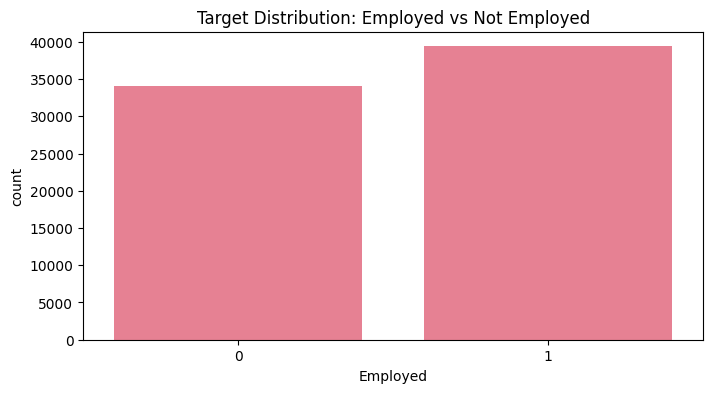

In [35]:
#Dataset Overview
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"Numeric features: {len(df_clean.select_dtypes(include=['int64','float64']).columns)}")
print(f"Categorical features: {len(df_clean.select_dtypes(include=['object']).columns)}")

# Summary stats for numeric features
print(df_clean.describe().T[['mean','std','min','25%','50%','75%','max']].round(2))

# Check for missing values
missing_summary = df_clean.isnull().sum()
print(missing_summary[missing_summary > 0].sort_values(ascending=False))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.countplot(x='Employed', data=df_clean)
plt.title("Target Distribution: Employed vs Not Employed")
plt.show()


## 5. Feature Correlation Analysis

In [36]:
# Quick correlation analysis
if X_train is not None:
    print(" CORRELATION ANALYSIS")
    print("=" * 30)

    # Find highly correlated pairs
    correlation_matrix = X_train.corr()
    high_corr_pairs = []

    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.5:
                feature1 = correlation_matrix.columns[i]
                feature2 = correlation_matrix.columns[j]
                high_corr_pairs.append((feature1, feature2, corr_val))

    print(f" Found {len(high_corr_pairs)} highly correlated pairs (|r| > 0.5)")
    for f1, f2, corr in high_corr_pairs[:5]:  # Show top 5
        print(f"   • {f1} ↔ {f2}: {corr:.3f}")

    if len(high_corr_pairs) == 0:
        print("No problematic correlations - good for ML models!")

 CORRELATION ANALYSIS
 Found 26 highly correlated pairs (|r| > 0.5)
   • Programming_Score ↔ Web_Score: 0.501
   • Programming_Score ↔ Database_Score: 0.503
   • Programming_Score ↔ ComputerSkills: 0.656
   • Web_Score ↔ Database_Score: 0.559
   • Web_Score ↔ Has_Web: 0.630


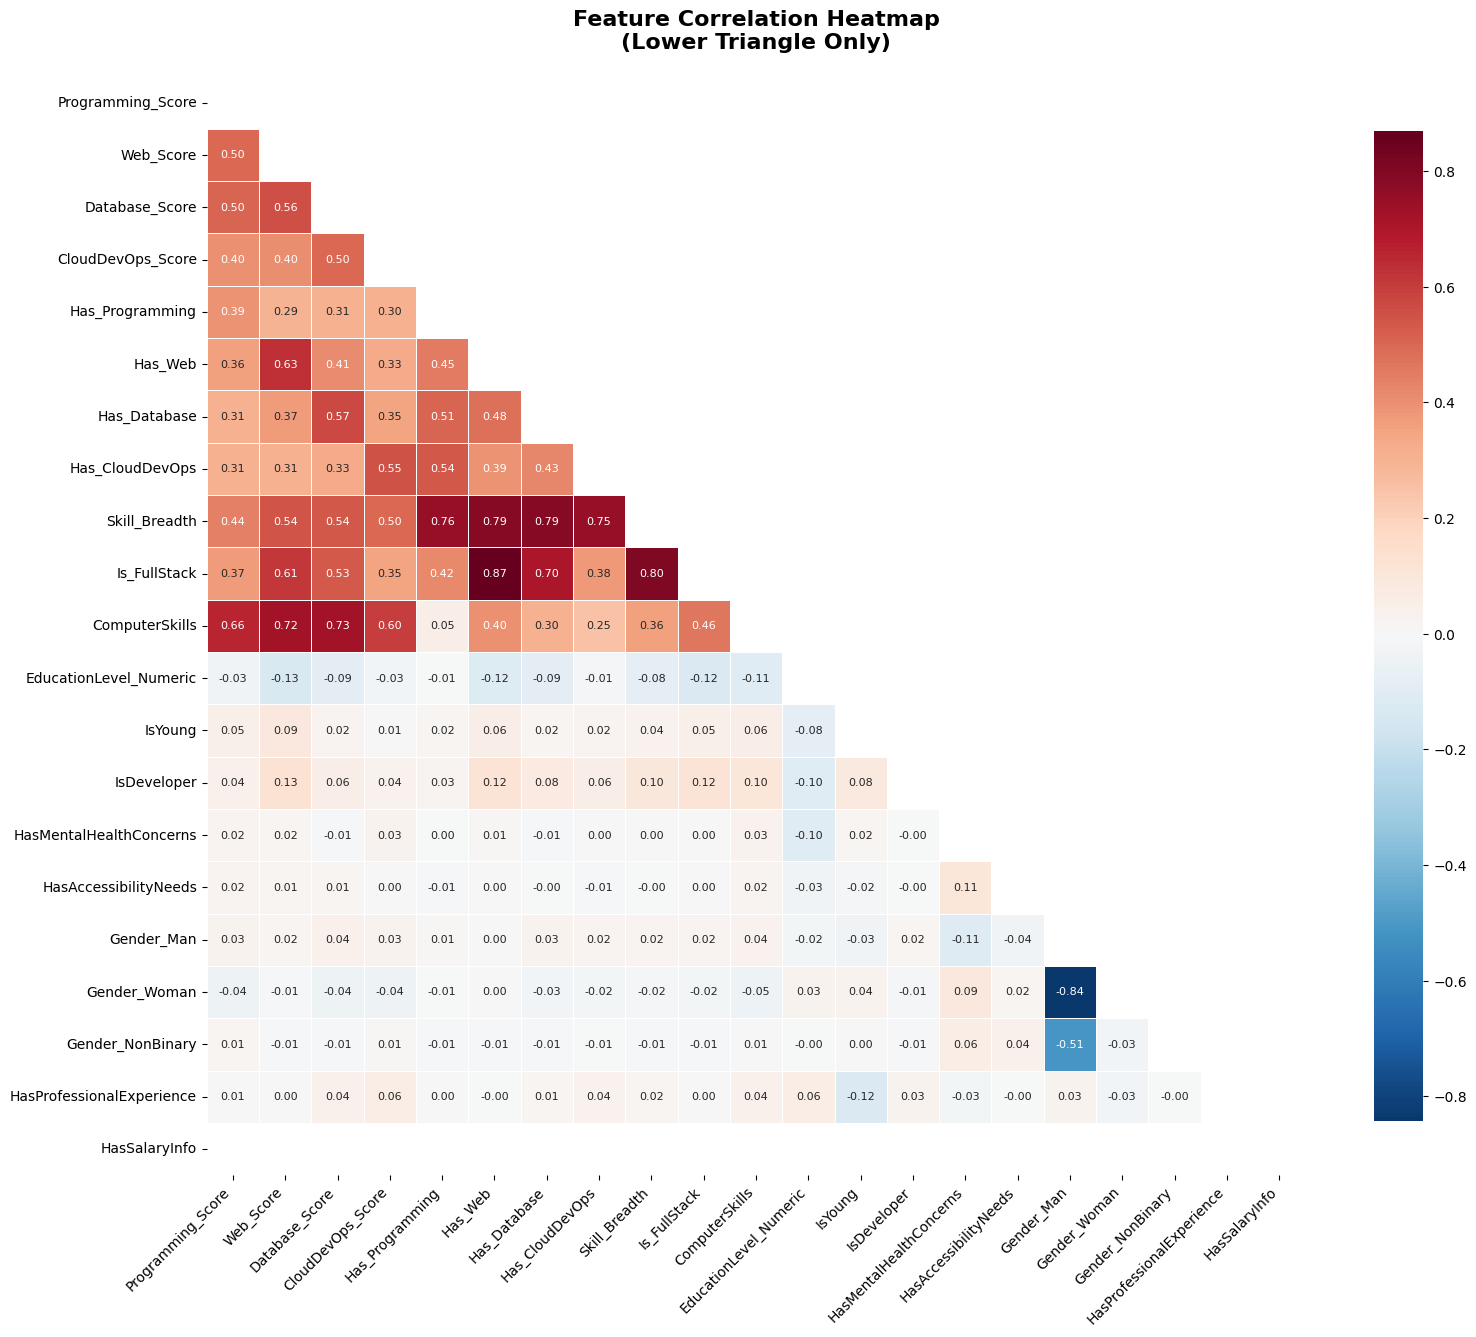

 Correlation analysis complete!
 Red: Positive correlations |  Blue: Negative correlations |  White: No correlation


In [37]:
# Generate correlation heatmap
if X_train is not None:
    plt.figure(figsize=(16, 14))

    # Calculate correlation matrix and create heatmap
    correlation_matrix = X_train.corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8}, fmt='.2f',
                annot_kws={'size': 8})

    plt.title('Feature Correlation Heatmap\n(Lower Triangle Only)', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(" Correlation analysis complete!")
    print(" Red: Positive correlations |  Blue: Negative correlations |  White: No correlation")

## 7. Employment vs Features Analysis

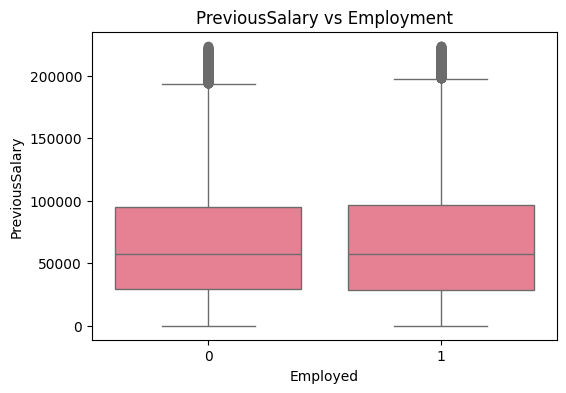

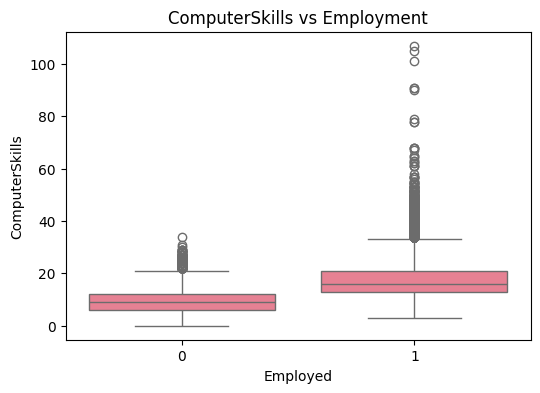

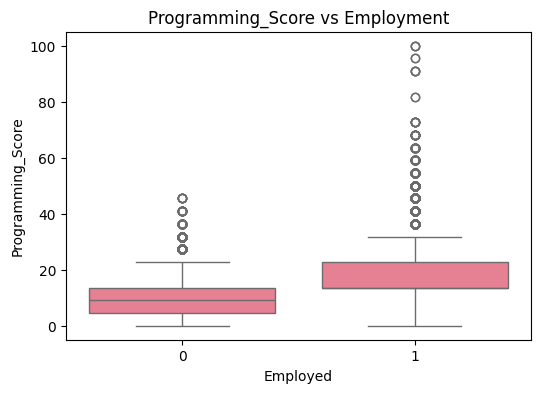

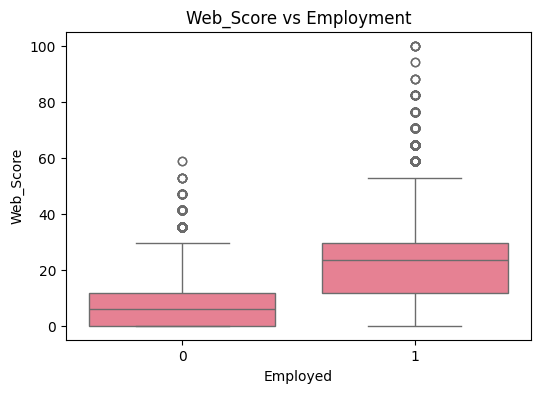

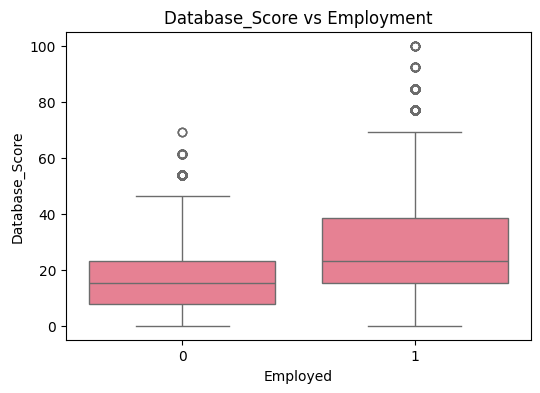

In [48]:
numeric_cols = df_clean.select_dtypes(include=['int64','float64']).columns.drop('Employed')

for col in numeric_cols[:5]:
    plt.figure(figsize=(6,4))
    # show first 5 for quick overview
    sns.boxplot(x='Employed', y=col, data=df_clean)
    plt.title(f"{col} vs Employment")
    plt.show()


<Figure size 600x400 with 0 Axes>

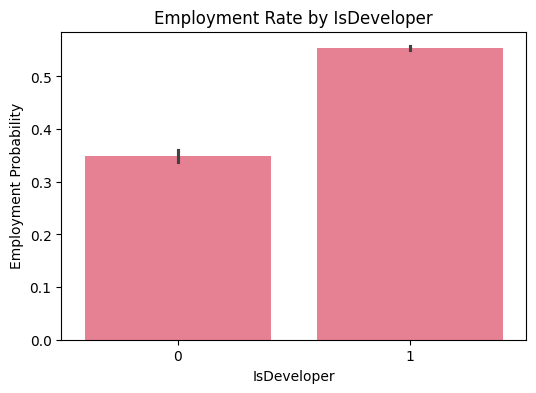

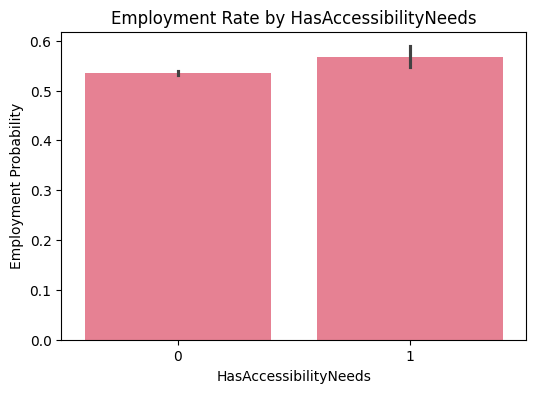

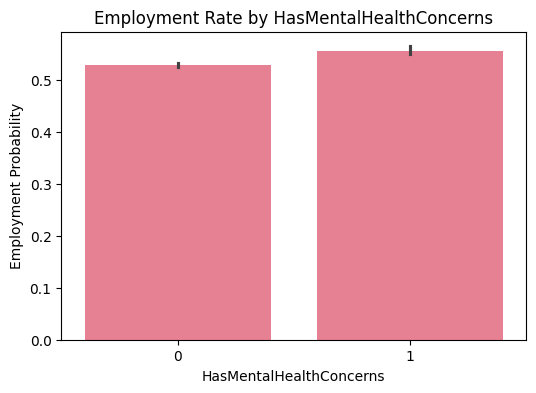

In [50]:
cat_cols = ['Gender', 'IsDeveloper', 'HasAccessibilityNeeds', 'HasMentalHealthConcerns']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    if col in df_clean.columns:
        sns.barplot(x=col, y='Employed', data=df_clean, estimator=lambda x: sum(x)/len(x))
        plt.title(f"Employment Rate by {col}")
        plt.ylabel("Employment Probability")
        plt.show()


## 8. Key Insights and Conclusions

In [51]:
# EDA Summary
if X_train is not None and y_train is not None:
    print("EDA SUMMARY")
    print("=" * 30)

    print(f"Dataset: {len(X_train):,} training samples with {len(X_train.columns)} features")
    print(f"Target: {(y_train.iloc[:, 0] == 'Employed').mean():.1%} employed developers")
    print(f"Features: Technology scores + Binary flags + Demographics + Professional")
    print(f"Data Quality: No missing values, properly encoded, ready for ML")

    print(f"\n READY FOR MODEL TRAINING:")
    print("   • Balanced dataset with good feature engineering")
    print("   • Low multicollinearity between features")
    print("   • Comprehensive developer skill profiling")
    print("   • Next: Train classification models")

EDA SUMMARY
Dataset: 58,769 training samples with 21 features
Target: 0.0% employed developers
Features: Technology scores + Binary flags + Demographics + Professional
Data Quality: No missing values, properly encoded, ready for ML

 READY FOR MODEL TRAINING:
   • Balanced dataset with good feature engineering
   • Low multicollinearity between features
   • Comprehensive developer skill profiling
   • Next: Train classification models
